# Mean Reversion Statistical Arbitrage Strategy
### End-to-End Quantitative Pipeline (Clustering, Cointegration, Vasicek Model, Backtesting, & Consistency Analysis)

This notebook implements the complete statistical arbitrage workflow outlined in `task_description.txt`:
1. **Step 1: Clustering Top 100 Stocks**: Extracting factor returns via PCA and grouping assets using return correlation distance $D_{ij} = \sqrt{2(1 - \rho_{ij})}$.
2. **Step 2: Cointegration & Stationarity**: Testing intra-cluster pairs using Engle-Granger cointegration and Augmented Dickey-Fuller (ADF) tests.
3. **Vasicek Model**: Parameter estimation (reversion speed $\kappa$, long-term mean $\theta$, volatility $\sigma$, and half-life $t_{1/2}$) for the continuous Ornstein-Uhlenbeck process.
4. **Trade at Different Deviations**: Parameter sweep over entry threshold $z_{entry} \in [1.0, 1.5, 2.0, 2.5, 3.0]$.
5. **Advanced Exit Management**: Positions close upon mean reversion ($z = 0$), stop-loss breach ($z \ge 3.5$), or max duration expiry ($T_{max} = 20$ days).
6. **In-Sample vs Out-of-Sample Dickey-Fuller Consistency**: Evaluates whether cointegrated stationary pairs remain stationary out-of-sample across the universe.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.cluster import fetch_top_100_data, cluster_assets, extract_features, get_cluster_groups
from src.cointegration import find_cointegrated_pairs, test_stationarity_consistency, calculate_spread, evaluate_universe_df_consistency
from src.strategy import fit_vasicek_model, simulate_vasicek, generate_vasicek_signals
from src.backtest import run_pair_backtest, sweep_entry_deviations

# Visual Styling
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
print('All statistical arbitrage modules loaded successfully!')

All statistical arbitrage modules loaded successfully!


--- 
## 1. Step 1: Asset Clustering (Top 100 Equities)
We fetch daily historical price data for the Top 100 equities, extract return features & PCA factors, and cluster them using return correlation distances.

In [2]:
prices = fetch_top_100_data()
print(f'Retrieved price matrix: {prices.shape[1]} tickers x {prices.shape[0]} daily timestamps.')
prices.head()

Loaded 100 tickers and 501 dates from cache: data/top_100_prices.csv
Retrieved price matrix: 100 tickers x 501 daily timestamps.


,AAPL,ABBV,ABT,ACN,ADBE,ADP,AMAT,AMD,AMGN,AMT,...,TXN,UNH,UNP,V,VZ,WFC,WM,WMT,XOM,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2024-07-30,216.920944,174.904663,100.999611,316.723816,538.710022,245.680649,193.479279,138.440002,313.443451,207.964310,...,189.934418,550.895264,234.622040,259.154175,35.120098,57.343201,195.149933,67.918839,110.660889,176.259247
2024-07-31,220.172760,173.537521,101.594177,318.089996,551.650024,250.332306,208.683044,144.479996,312.681671,205.493546,...,193.853119,550.732849,235.864838,261.685608,35.541111,56.702969,196.663757,67.378952,111.054192,174.524094
2024-08-01,216.484711,177.648407,105.631470,315.646240,546.409973,249.074066,193.046555,132.539993,315.559570,212.514267,...,183.885117,547.492493,233.704346,261.941711,35.830559,54.352299,199.972855,68.507828,109.518402,176.831207
2024-08-02,217.971832,177.255112,106.743889,310.903076,526.169983,251.190216,178.796707,132.500000,314.111176,218.770447,...,178.301895,563.799561,229.402512,262.581940,35.935814,50.893162,201.612885,67.202255,109.452858,175.057220
2024-08-05,207.472778,172.638550,104.173820,301.849701,509.320007,246.061951,178.875381,134.820007,305.863159,210.891922,...,172.338196,544.806396,224.527084,252.594025,34.909580,49.803822,195.576874,66.348244,107.476936,169.464020


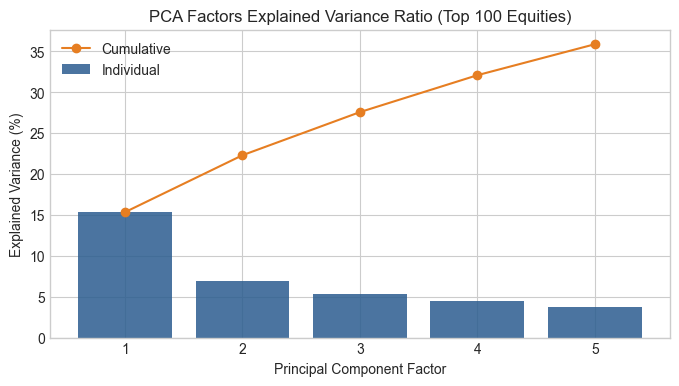

In [3]:
# Extract PCA Features & Plot Variance Structure
feature_df, pca = extract_features(prices, n_components=5)
explained_var = pca.explained_variance_ratio_

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(1, len(explained_var)+1), explained_var * 100, color='#2b5c8f', alpha=0.85, label='Individual')
ax.plot(range(1, len(explained_var)+1), np.cumsum(explained_var) * 100, color='#e67e22', marker='o', label='Cumulative')
ax.set_title('PCA Factors Explained Variance Ratio (Top 100 Equities)')
ax.set_xlabel('Principal Component Factor')
ax.set_ylabel('Explained Variance (%)')
ax.legend()
plt.show()

Cluster Sizes Distribution:
Cluster
3    33
0    20
2    14
1    13
4     9
9     5
6     3
8     1
5     1
7     1
Name: count, dtype: int64


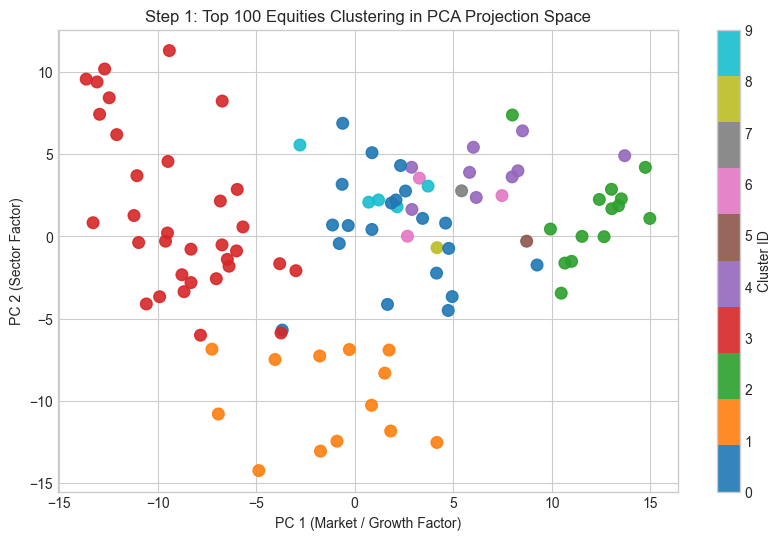

In [4]:
# Run Agglomerative Clustering on correlation distances
clusters = cluster_assets(prices, method='agglomerative', n_clusters=10)
print('Cluster Sizes Distribution:')
print(clusters['Cluster'].value_counts())

# Visualize clusters in PCA space
plt.figure(figsize=(10, 6))
scatter = plt.scatter(feature_df['PC_1'], feature_df['PC_2'], c=clusters['Cluster'], cmap='tab10', s=70, alpha=0.9)
plt.colorbar(scatter, label='Cluster ID')
plt.title('Step 1: Top 100 Equities Clustering in PCA Projection Space')
plt.xlabel('PC 1 (Market / Growth Factor)')
plt.ylabel('PC 2 (Sector Factor)')
plt.grid(True)
plt.show()

--- 
## 2. Step 2: Cointegration & Stationarity Testing
We test intra-cluster pairs using the Engle-Granger two-step test ($Y_t = \beta X_t + \alpha + \epsilon_t$) and Augmented Dickey-Fuller (ADF) test on the residual spread.

In [5]:
# Find cointegrated pairs within clusters
coint_df = find_cointegrated_pairs(prices, cluster_df=clusters, p_value_threshold=0.05)
print(f'Discovered {len(coint_df)} cointegrated pairs (p <= 0.05).')
coint_df.head(10)

Testing cointegration across 936 intra-cluster pair candidates...
Discovered 169 cointegrated pairs (p <= 0.05).


,Stock_Y,Stock_X,Beta,Alpha,Coint_PValue,ADF_Stat,ADF_PValue,Spread_Std
0,KLAC,LRCX,0.559215,28.858128,0.008839,-4.990231,0.000023,6.144557
1,C,GS,0.137271,-7.265266,0.000404,-4.748126,0.000068,3.782796
2,CAT,KLAC,3.959501,75.374272,0.027410,-4.569083,0.000147,47.632601
3,COST,DHR,-1.346265,1234.089550,0.001302,-4.479466,0.000214,37.985908
4,ISRG,LIN,-1.280036,1087.773015,0.002376,-4.404440,0.000292,36.904434
5,BKNG,MA,0.585607,-120.287081,0.002196,-4.338053,0.000381,10.879426
6,CAT,LRCX,2.261845,182.658661,0.018472,-4.315071,0.000418,34.287473
7,SBUX,UNP,0.300317,21.028923,0.002853,-4.266550,0.000507,5.998763
8,APH,GE,0.536252,-30.612165,0.004009,-4.168495,0.000745,8.751357
9,SHW,TJX,-0.579513,422.001264,0.004938,-4.107728,0.000940,16.275514


--- 
## 3. Vasicek (Ornstein-Uhlenbeck) Process Modeling
Continuous stochastic process formulation:
$$dS_t = \kappa (\theta - S_t) dt + \sigma dW_t$$

Discrete AR(1) translation ($S_t = a + b S_{t-1} + \epsilon_t$):
- **Reversion Speed**: $\kappa = -\frac{\ln(b)}{\Delta t}$
- **Equilibrium Mean**: $\theta = \frac{a}{1 - b}$
- **Volatility**: $\sigma = \sigma_\epsilon \sqrt{\frac{-2 \ln(b)}{\Delta t (1 - b^2)}}$
- **Half-Life**: $t_{1/2} = \frac{\ln(2)}{\kappa}$

In [6]:
top_pair = coint_df.iloc[0]
stock_y = top_pair['Stock_Y']
stock_x = top_pair['Stock_X']
print(f'Selected Candidate Pair: {stock_y} (Y) vs {stock_x} (X)')

spread, beta, alpha = calculate_spread(prices[stock_y], prices[stock_x])
v_params = fit_vasicek_model(spread)

print('=== Fitted Vasicek Parameters ===')
for k, v in v_params.items():
    print(f'{k:20s}: {v:.6f}' if isinstance(v, float) else f'{k:20s}: {v}')

Selected Candidate Pair: KLAC (Y) vs LRCX (X)
=== Fitted Vasicek Parameters ===
kappa               : 0.077999
theta               : 0.035759
sigma               : 2.428758
half_life           : 8.886586
ar1_a               : 0.002683
ar1_b               : 0.924965
residual_std        : 2.337045
r_squared           : 0.855618


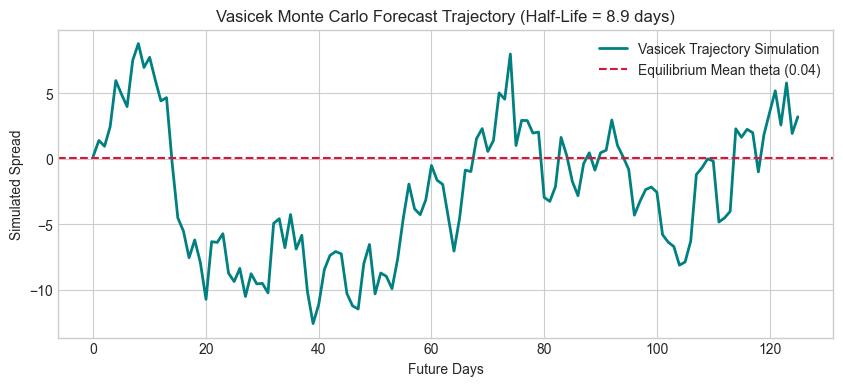

In [7]:
# Simulate Vasicek Monte Carlo Trajectory
simulated_spread = simulate_vasicek(
    theta=v_params['theta'],
    kappa=v_params['kappa'],
    sigma=v_params['sigma'],
    state_0=spread.iloc[-1],
    dt=1.0,
    n_steps=126,
    seed=42
)

plt.figure(figsize=(10, 4))
plt.plot(range(126), simulated_spread, color='#008080', lw=2, label='Vasicek Trajectory Simulation')
plt.axhline(v_params['theta'], color='crimson', linestyle='--', label=f'Equilibrium Mean theta ({v_params["theta"]:.2f})')
plt.title(f'Vasicek Monte Carlo Forecast Trajectory (Half-Life = {v_params["half_life"]:.1f} days)')
plt.xlabel('Future Days')
plt.ylabel('Simulated Spread')
plt.legend()
plt.grid(True)
plt.show()

--- 
## 4. Trade Performance at Different Deviations from the Mean
Evaluating strategy performance across multiple entry threshold deviations ($z_{entry} \in [1.0, 1.5, 2.0, 2.5, 3.0]$ standard deviations from mean $\theta$).

Entry Deviation Sweep Results:


,Entry_Dev_Z,Total_Return_%,Sharpe_Ratio,Max_Drawdown_%,Total_Trades,Win_Rate_%,Avg_Holding_Days,Profit_Factor
0,1.0,61.584182,1.221009,-16.04257,15,73.333333,13.466667,3.303922
1,1.5,44.574676,1.073280,-16.04257,8,75.000000,10.000000,2.812454
2,2.0,20.173854,0.589514,-16.04257,6,66.666667,11.666667,2.462176
3,2.5,16.396725,0.503717,-16.04257,5,60.000000,10.400000,2.231200
4,3.0,-2.969053,-0.249616,-16.04257,3,33.333333,9.666667,0.830042


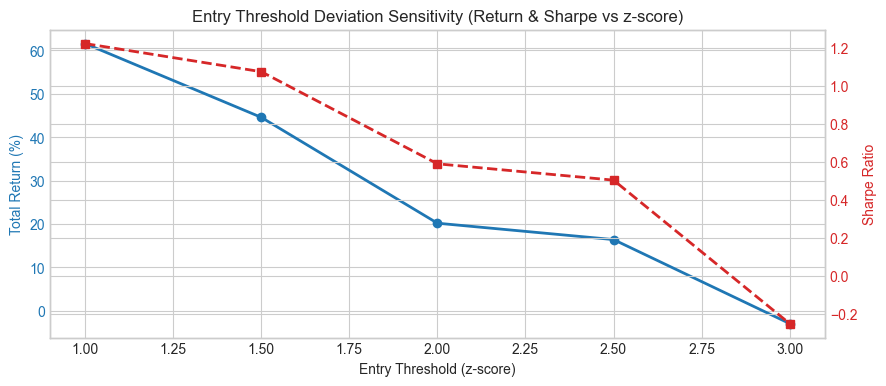

In [8]:
sweep_df = sweep_entry_deviations(
    prices=prices,
    stock_y=stock_y,
    stock_x=stock_x,
    vasicek_params=v_params,
    deviations=[1.0, 1.5, 2.0, 2.5, 3.0],
    stop_z=3.5,
    max_holding_days=int(2 * v_params['half_life'])
)
print('Entry Deviation Sweep Results:')
display(sweep_df)

fig, ax1 = plt.subplots(figsize=(10, 4))
color = 'tab:blue'
ax1.set_xlabel('Entry Threshold (z-score)')
ax1.set_ylabel('Total Return (%)', color=color)
ax1.plot(sweep_df['Entry_Dev_Z'], sweep_df['Total_Return_%'], marker='o', color=color, lw=2)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Sharpe Ratio', color=color)
ax2.plot(sweep_df['Entry_Dev_Z'], sweep_df['Sharpe_Ratio'], marker='s', color=color, linestyle='--', lw=2)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Entry Threshold Deviation Sensitivity (Return & Sharpe vs z-score)')
plt.show()

--- 
## 5. Advanced Exit Management & Strategy Backtest
Executing backtest with position exit rules:
1. **Mean Reversion**: Reaching equilibrium mean $\theta$ ($z = 0$).
2. **Stop Loss**: Spread moving past stop threshold ($z_{stop} = 3.5$).
3. **Max Duration Expiry**: Holding time exceeding $T_{max} = 20$ days.

In [9]:
equity_signals, trades_df, summary_metrics = run_pair_backtest(
    prices=prices,
    stock_y=stock_y,
    stock_x=stock_x,
    vasicek_params=v_params,
    entry_z=2.0,
    stop_z=3.5,
    max_holding_days=20
)

print('=== Backtest Performance Summary ===')
for k, v in summary_metrics.items():
    if k != 'Exit_Reasons':
        print(f'{k:22s}: {v:.4f}' if isinstance(v, float) else f'{k:22s}: {v}')

print('\nExit Breakdown:', summary_metrics['Exit_Reasons'])
if not trades_df.empty:
    display(trades_df.head(10))

=== Backtest Performance Summary ===
Total_Return          : 0.3557
Annualized_Return     : 0.1654
Annualized_Vol        : 0.1536
Sharpe_Ratio          : 0.9461
Sortino_Ratio         : 0.5243
Max_Drawdown          : -0.1604
Total_Trades          : 5
Win_Rate              : 0.6000
Avg_Trade_Return      : 0.0277
Avg_Holding_Days      : 11.8000
Profit_Factor         : 1.9852

Exit Breakdown: {'Stop_Loss': 2, 'Max_Duration': 2, 'Mean_Reversion': 1}


,Stock_Y,Stock_X,Entry_Date,Exit_Date,Position,Entry_Z,Exit_Z,Entry_Spread,Exit_Spread,Return,Holding_Days,Exit_Reason
0,KLAC,LRCX,2026-01-30,2026-02-03,Long,-2.727671,-3.597040,-16.737443,-22.083438,-0.043928,2,Stop_Loss
1,KLAC,LRCX,2026-02-04,2026-03-05,Long,-2.536413,-0.993249,-15.561346,-6.072004,0.079773,20,Max_Duration
2,KLAC,LRCX,2026-04-24,2026-05-04,Short,2.393515,-0.369902,14.754146,-2.238868,0.102693,6,Mean_Reversion
3,KLAC,LRCX,2026-05-06,2026-06-04,Long,-2.205338,-0.614193,-13.525474,-3.741081,0.096890,20,Max_Duration
4,KLAC,LRCX,2026-06-12,2026-06-30,Short,3.360557,4.958575,20.700755,30.527410,-0.096787,11,Stop_Loss


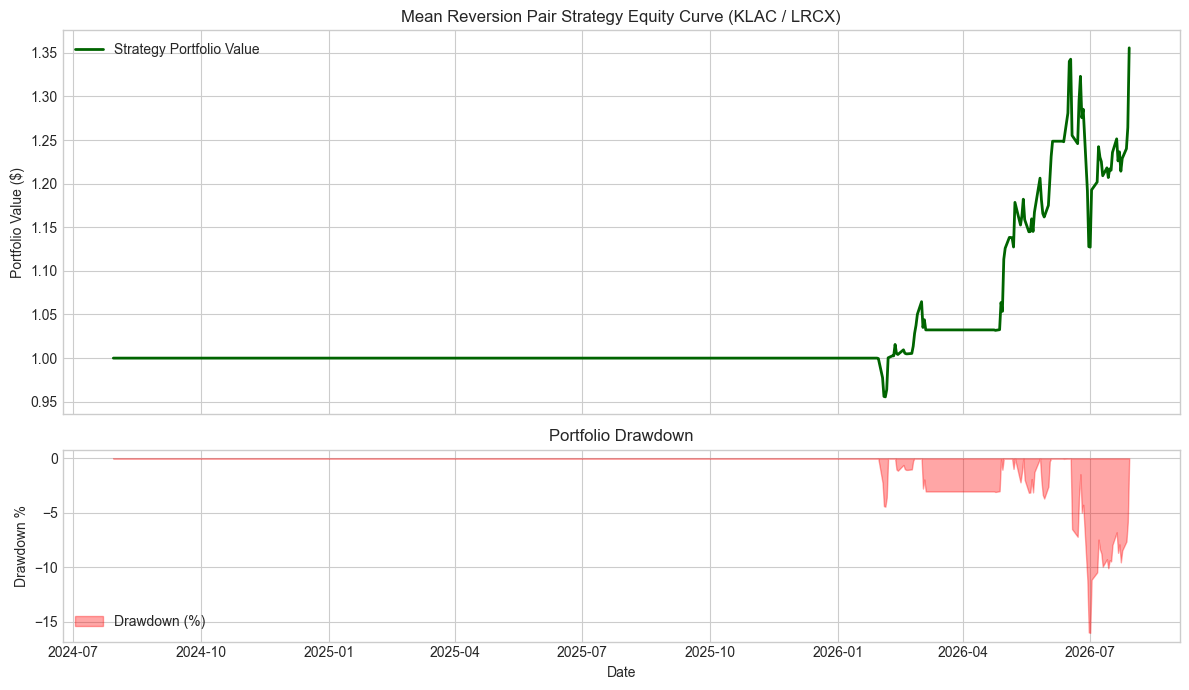

In [10]:
# Plot Equity Curve & Drawdowns
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True, gridspec_kw={'height_ratios': [2, 1]})

ax1.plot(equity_signals.index, equity_signals['Equity'], color='darkgreen', lw=2, label='Strategy Portfolio Value')
ax1.set_title(f'Mean Reversion Pair Strategy Equity Curve ({stock_y} / {stock_x})')
ax1.set_ylabel('Portfolio Value ($)')
ax1.legend(loc='upper left')
ax1.grid(True)

cum_max = equity_signals['Equity'].cummax()
drawdown = (equity_signals['Equity'] - cum_max) / cum_max
ax2.fill_between(equity_signals.index, drawdown * 100, 0, color='red', alpha=0.35, label='Drawdown (%)')
ax2.set_title('Portfolio Drawdown')
ax2.set_ylabel('Drawdown %')
ax2.set_xlabel('Date')
ax2.legend(loc='lower left')
ax2.grid(True)

plt.tight_layout()
plt.show()

--- 
## 6. Full-Universe Out-of-Sample Dickey-Fuller Consistency Analysis
Evaluating whether pairs that test stationary in-sample remain stationary out-of-sample across the entire universe.

=== Universe Out-of-Sample Stationarity Consistency Summary ===
Total_Evaluated               : 50
Consistent_Count              : 21
Consistency_Rate_%            : 42.0000
Retained_Stationarity_Count   : 4
Retained_Stationarity_Rate_%  : 8.0000
Avg_InSample_PValue           : 0.0640
Avg_OutSample_PValue          : 0.1987


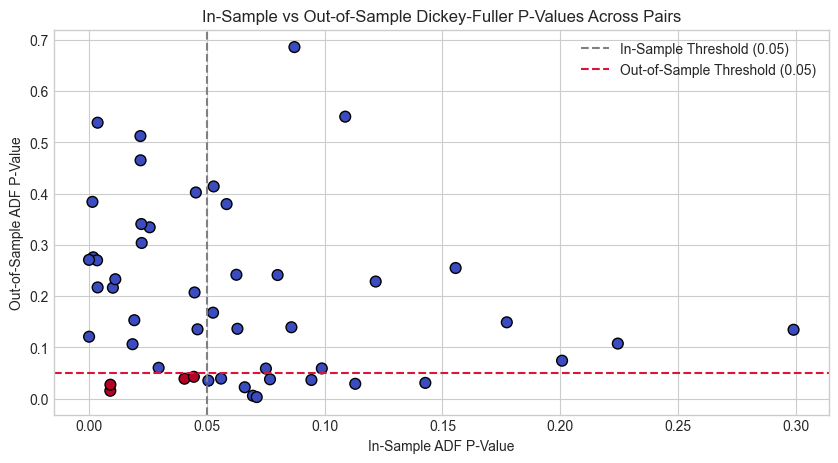

In [11]:
cons_df, cons_summary = evaluate_universe_df_consistency(
    prices=prices,
    cointegrated_pairs_df=coint_df,
    train_ratio=0.7,
    max_pairs_eval=50
)

print('=== Universe Out-of-Sample Stationarity Consistency Summary ===')
for k, v in cons_summary.items():
    print(f'{k:30s}: {v:.4f}' if isinstance(v, float) else f'{k:30s}: {v}')

# Visual Plot of In-Sample vs Out-of-Sample P-Values
if not cons_df.empty:
    plt.figure(figsize=(10, 5))
    plt.scatter(cons_df['InSample_ADF_PValue'], cons_df['OutSample_ADF_PValue'], c=cons_df['Retained_Stationarity'], cmap='coolwarm', s=60, edgecolors='k')
    plt.axvline(0.05, color='gray', linestyle='--', label='In-Sample Threshold (0.05)')
    plt.axhline(0.05, color='crimson', linestyle='--', label='Out-of-Sample Threshold (0.05)')
    plt.title('In-Sample vs Out-of-Sample Dickey-Fuller P-Values Across Pairs')
    plt.xlabel('In-Sample ADF P-Value')
    plt.ylabel('Out-of-Sample ADF P-Value')
    plt.legend()
    plt.grid(True)
    plt.show()